# Student Dropout Risk Scoring with Regression for Early Intervention

## Objective

The objective of this analysis is to extend the previous `student dropout prediction` experiment by reframing the problem as a continuous risk estimation task for early intervention.

Instead of producing only a binary classification outcome, the selected model is used to generate a continuous dropout-related risk score between 0 and 1 for each student. This score is later expressed as a percentage to support easier interpretation by non-technical stakeholders.

The analysis follows a structured workflow consisting of:

  1. Data Preparation  
  2. Risk Model Training  
  3. Continuous Risk Score Construction  
  4. Risk Category Design  
  5. Threshold Analysis  
  6. Calibration Analysis  
  7. Support Capacity Simulation  
  8. Practical and Ethical Interpretation  

This notebook uses the same binary observed outcome as the previous analysis, but reframes the modeling task as continuous risk estimation. A regression model is trained on the binary target coded as 0 for Graduate and 1 for Dropout, allowing the output to be interpreted as a continuous dropout-related risk score between 0 and 1.

# 1. Import Libraries

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
  mean_absolute_error,
  mean_squared_error,
  r2_score,
  brier_score_loss,
  accuracy_score,
  precision_score,
  recall_score,
  f1_score,
  confusion_matrix,
  roc_auc_score
)

from sklearn.calibration import calibration_curve

sns.set(style="whitegrid")

# 2. Load Dataset

In this notebook, the same dataset is used as in the previous student dropout analysis. However, the goal is now different. Instead of focusing only on binary classification, the dataset is used to build a `regression-based risk scoring framework` that estimates a continuous dropout-related risk score between 0 and 1.

## 2.1. Load Dataset

In [6]:
df = pd.read_csv("../datasets/data.csv", sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2.2. Clean Column Names

Before continuing with the analysis, the column names are cleaned to remove unnecessary whitespace, tab characters, and quotation marks.

In [7]:
# Clean column names
df.columns = df.columns.str.replace("\t", "")
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace("'", "")

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mothers qualification,Fathers qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# 3. Dataset Overview

Before preparing the data for risk scoring, it is important to understand the overall structure of the dataset. This includes checking the number of observations and features, inspecting the variable names and data types, verifying whether missing values are present, and reviewing the distribution of the target variable.

## 3.1. Dataset Shape

In [8]:
df.shape

(4424, 37)

## 3.2. Column Names

In [9]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mothers qualification', 'Fathers qualification', 'Mothers occupation',
       'Fathers occupation', 'Admission grade', 'Displaced',
       'Educational special needs', 'Debtor', 'Tuition fees up to date',
       'Gender', 'Scholarship holder', 'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd sem (grade)'

## 3.3. Data Types

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mothers qualification                           4424 non-null   int64  
 9   Fathers qualification                           4424

## 3.4. Missing Values Check

In [11]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

_The dataset was checked for missing values before further preprocessing. The results show that no features contain missing data. Therefore, no imputation is required for this analysis._

## 3.5. Target Variable Distribution

The original dataset contains **three** possible academic outcomes:

* Dropout  
* Enrolled  
* Graduate  

Since the purpose of the project is to study dropout-related risk using known final outcomes, the distribution of the original target variable is first inspected before filtering is applied.

In [12]:
df["Target"].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

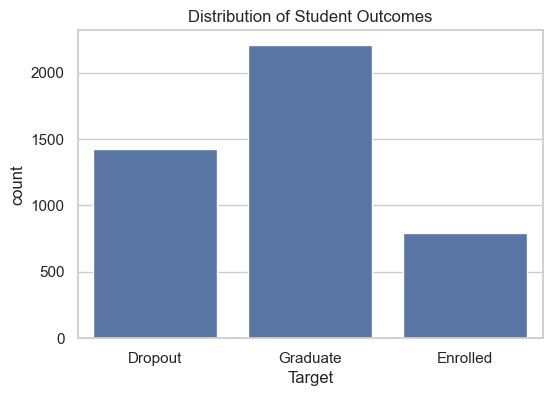

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="Target", data=df)

plt.title("Distribution of Student Outcomes")
plt.show()

## 3.6. Interpretation

The dataset includes three academic outcomes, but only two of them represent known final states. Since the objective of this notebook is to estimate continuous dropout-related risk from known historical outcomes, the next section prepares the data by filtering the target variable, removing leakage-related features, encoding categorical variables, and constructing the ethical feature set used for regression-based risk scoring.

# 4. Data Preparation

Before generating risk scores, the dataset must be prepared in a way that remains consistent with the previous notebook. This includes filtering the target variable, removing features that may introduce data leakage, reducing unnecessary categorical complexity, encoding categorical variables, and excluding sensitive demographic and socioeconomic attributes.

## 4.1. Filter Target Variable

The `Enrolled` category is removed because it does not represent a known final academic outcome. The remaining target is coded as 0 for Graduate and 1 for Dropout.

Although the observed target remains binary, it is used here as the basis for a regression-based risk estimation task. Because the target is coded on a 0 to 1 scale, the regression model can later produce a continuous output that is interpreted as dropout-related risk.

In [14]:
# Remove whitespace from target values
df["Target"] = df["Target"].str.strip()

# Remove records with unknown final outcome
df = df[df["Target"] != "Enrolled"]

# Convert target to binary
df["Target"] = df["Target"].map({
  "Dropout": 1,
  "Graduate": 0
})

df["Target"].value_counts()

Target
0    2209
1    1421
Name: count, dtype: int64

In [15]:
print(df["Target"].unique())

[1 0]


_After removing the `Enrolled` category, the target variable becomes a binary observed outcome that can be used as the basis for regression-based risk estimation._

## 4.2. Remove Second Semester Features

Because the goal of the project is **early risk detection**, only variables that would realistically be available at an early stage of the student journey should be used.

`Second-semester` features may introduce data leakage, since they contain information from a later point in time and could make the model unrealistically strong. For this reason, they are removed before training the risk model.

In [16]:
df = df.drop(columns=[
  "Curricular units 2nd sem (credited)",
  "Curricular units 2nd sem (enrolled)",
  "Curricular units 2nd sem (evaluations)",
  "Curricular units 2nd sem (approved)",
  "Curricular units 2nd sem (grade)",
  "Curricular units 2nd sem (without evaluations)"
])

df.shape

(3630, 31)

## 4.3. Define Feature Matrix and Target Variable

After filtering the target variable and removing leakage-related features, the dataset is divided into:

* X = predictor variables  
* y = target variable  

In [17]:
X = df.drop("Target", axis=1)
y = df["Target"]

## 4.4. Reduce High-Cardinality Categories

Some categorical variables contain many unique categories. To reduce `dimensionality`, rare categories are grouped into an **Other** category while the most frequent categories are retained.

This helps simplify the feature space without removing the variables entirely.

In [18]:
def group_rare_categories(df, column, top_n=10):
  top_categories = df[column].value_counts().nlargest(top_n).index
  df[column] = df[column].apply(lambda x: x if x in top_categories else "Other")
  return df

In [19]:
high_cardinality_cols = [
  "Course",
  "Nacionality",
  "Mothers occupation",
  "Fathers occupation",
  "Mothers qualification",
  "Fathers qualification"
]

for col in high_cardinality_cols:
  df = group_rare_categories(df, col, top_n=10)

print("Unique values after grouping:")
for col in high_cardinality_cols:
  print(col, ":", df[col].nunique())

Unique values after grouping:
Course : 11
Nacionality : 11
Mothers occupation : 11
Fathers occupation : 11
Mothers qualification : 11
Fathers qualification : 11


## 4.5. Apply One-Hot Encoding

Some variables in the dataset are categorical but encoded as numeric category labels. These should not be treated as continuous numerical values, because they do not represent meaningful ordered relationships.

`One-hot encoding` is therefore applied to convert these categorical variables into binary features.

In [20]:
categorical_cols = [
  "Marital status",
  "Application mode",
  "Course",
  "Nacionality",
  "Mothers qualification",
  "Fathers qualification",
  "Mothers occupation",
  "Fathers occupation"
]

In [21]:
X = df.drop("Target", axis=1)
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("New shape:", X.shape)

New shape: (3630, 104)


## 4.6. Apply Ethical Feature Selection

In the previous notebook, an ethical comparison was performed by removing potentially sensitive demographic and socioeconomic attributes. Since this notebook focuses on responsible and interpretable risk scoring, the ethical version of the feature set is used here.

The following sensitive attributes are excluded:

* Gender  
* Nacionality  
* Mothers qualification  
* Fathers qualification  
* Mothers occupation  
* Fathers occupation  

This helps reduce the risk that the model relies directly on demographic identity or family background when generating support-oriented risk scores.

In [22]:
sensitive_prefixes = [
  "Gender",
  "Nacionality",
  "Mothers qualification",
  "Fathers qualification",
  "Mothers occupation",
  "Fathers occupation"
]

cols_to_drop = [
  col for col in X.columns
  if any(col.startswith(prefix) for prefix in sensitive_prefixes)
]

X_eth = X.drop(columns=cols_to_drop)

print("Original number of features:", X.shape[1])
print("Ethical dataset number of features:", X_eth.shape[1])

Original number of features: 104
Ethical dataset number of features: 53


## 4.7. Train/Test Split

To evaluate the risk model on unseen data, the ethical dataset is split into training and testing sets. Stratification is used so that both sets preserve the original class distribution.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
  X_eth,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (2904, 53)
Test set: (726, 53)


## 4.8. Interpretation

After preprocessing, the dataset is ready for risk model training. Although the observed target remains a binary dropout outcome, the purpose of this notebook is no longer to produce only a hard class label. Instead, the selected regression model will generate a continuous dropout-related risk score between 0 and 1.

This score can later be converted into a percentage, used to rank students by estimated risk, grouped into practical categories, and thresholded for intervention planning.

# 5. Train the Ethical Gradient Boosting Regressor

In the previous notebook, several original and ethical models were trained and compared. In this notebook, the goal is no longer to compare multiple classification algorithms, but to train a single model that can generate an interpretable continuous dropout-related risk score.

For this purpose, the ethical gradient boosting approach is used in regression form. The model is trained on the target coded as 0 for Graduate and 1 for Dropout, allowing it to produce a continuous output between 0 and 1 that can later be interpreted as dropout-related risk.

## 5.1. Model Selection Justification

The `Ethical Gradient Boosting` approach is selected for three main reasons:

  * it performed strongly in earlier experiments
  * it captures non-linear relationships in structured tabular data
  * it can be used here in regression form to generate a continuous dropout-related risk score rather than only a hard class label

This makes the model especially suitable for early intervention analysis, where the goal is not only to classify students into outcome groups, but also to estimate how strongly each student profile is associated with historical dropout patterns.

## 5.2. Train the Model

The selected `Gradient Boosting Regressor` model is trained using the **ethical** training dataset prepared in the previous section.

In [24]:
# Initialize the selected risk model
risk_model = GradientBoostingRegressor(
  n_estimators=200,
  learning_rate=0.05,
  random_state=42
)

# Train the model
risk_model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

## 5.3. Make Predictions

After training the model, continuous risk scores are generated for the test set.

Because the regressor is trained on a target coded as 0 for Graduate and 1 for Dropout, each predicted value can be interpreted as a dropout-related risk score. Values closer to 1 indicate stronger similarity to historical dropout cases, while values closer to 0 indicate stronger similarity to historical graduate cases.

Since a regression model is not strictly constrained to remain within the target range, the predicted values are clipped to the interval from 0 to 1 to preserve interpretability as percentage-based risk scores.

In [27]:
# Predict continuous dropout-related risk scores
y_score = risk_model.predict(X_test)

# Keep scores within the interpretable 0-1 range
y_score = np.clip(y_score, 0, 1)

## 5.4. Evaluate the Ethical Gradient Boosting

Before using the predicted risk scores in later analysis, the selected model is evaluated on the test set. Because the notebook is framed as a regression-based risk estimation task, the main evaluation focuses on regression-oriented metrics and score quality rather than only hard classification performance.

In [28]:
mae = mean_absolute_error(y_test, y_score)
mse = mean_squared_error(y_test, y_score)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_score)
brier = brier_score_loss(y_test, y_score)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)
print("Brier Score:", brier)

MAE: 0.18649891200557894
MSE: 0.08151133514441027
RMSE: 0.28550190042171397
R²: 0.65774434004704
Brier Score: 0.08151133514441027


## 5.5. Interpretation

The selected `Ethical Gradient Boosting Regressor` produces a continuous dropout-related risk score for each student rather than only a hard class label.

The evaluation results show that these scores remain meaningfully aligned with the observed student outcomes. This is important because the purpose of the notebook is not only to decide whether a student belongs to a dropout or graduate category, but to estimate the degree of dropout-related risk on a continuous scale.

Such continuous scores are more suitable for conversion into percentages, easier to communicate to non-technical stakeholders, and more useful for ranking students or designing gradual intervention policies.

# 6. Risk Score Construction

The main purpose of this notebook is to move beyond a simple binary outcome and translate the model’s continuous regression output into a more interpretable dropout-related risk score.

In this notebook, each student receives a continuous score between 0 and 1. A higher score means that the student’s profile is more similar to historical patterns associated with dropout, while a lower score indicates a profile more similar to students who graduate.

This does not mean that the model measures student `struggle` directly. Instead, the score should be understood as an estimated dropout-related risk level derived from the regression model.

## 6.1. Define the Risk Score

The predicted regression output is used as the student risk score.

This means that:

  * a value close to **0** indicates **low** estimated dropout-related risk
  * a value close to **1** indicates **high** estimated dropout-related risk

These continuous scores provide a more gradual interpretation of model output than a simple class label and are therefore more suitable for early warning and support-oriented decision-making.

## 6.2. Convert Risk Score to Percentage

To make the model output easier to interpret, the the continuous risk scores are converted into **percentage form**.

For example:

  * 0.20 becomes 20% estimated dropout-related risk
  * 0.75 becomes 75% estimated dropout-related risk

In [29]:
risk_scores = y_score
risk_scores_percent = risk_scores * 100

## 6.3. Create Results Table

To inspect the model output more clearly, a results table is created containing:

  * the actual student outcome
  * the predicted continuous risk score
  * the percentage-based risk score

This makes the risk scoring framework more transparent and allows individual predictions to be reviewed more easily.

In [30]:
results_df = pd.DataFrame({
  "Actual Outcome": y_test.values,
  "Predicted Risk Score": risk_scores,
  "Risk Score (%)": risk_scores_percent
})

results_df.head(10)

,Actual Outcome,Predicted Risk Score,Risk Score (%)
0,0,0.010401,1.040075
1,0,0.162577,16.257693
2,1,0.340720,34.071973
3,0,0.283259,28.325882
4,0,0.600824,60.082411
5,0,0.027494,2.749365
6,0,0.221548,22.154784
7,1,0.957530,95.753018
8,0,0.501984,50.198402
9,1,0.753585,75.358542


## 6.4. Add Human-Readable Outcome Labels

To make the results table easier to interpret, the binary values are converted into descriptive labels.

In [31]:
results_df["Actual Label"] = results_df["Actual Outcome"].map({
  1: "Dropout",
  0: "Graduate"
})

results_df.head(10)

,Actual Outcome,Predicted Risk Score,Risk Score (%),Actual Label
0,0,0.010401,1.040075,Graduate
1,0,0.162577,16.257693,Graduate
2,1,0.340720,34.071973,Dropout
3,0,0.283259,28.325882,Graduate
4,0,0.600824,60.082411,Graduate
5,0,0.027494,2.749365,Graduate
6,0,0.221548,22.154784,Graduate
7,1,0.957530,95.753018,Dropout
8,0,0.501984,50.198402,Graduate
9,1,0.753585,75.358542,Dropout


## 6.5. Sort Students by Risk Score

To better understand how the model ranks students, the results table can be sorted from highest to lowest predicted risk.

This makes it easier to inspect which students are being flagged as the most at risk.

In [32]:
results_df_sorted = results_df.sort_values(by="Risk Score (%)", ascending=False)

results_df_sorted.head(10)

,Actual Outcome,Predicted Risk Score,Risk Score (%),Actual Label
721,1,1.0,100.0,Dropout
324,1,1.0,100.0,Dropout
323,1,1.0,100.0,Dropout
328,1,1.0,100.0,Dropout
335,1,1.0,100.0,Dropout
41,1,1.0,100.0,Dropout
367,1,1.0,100.0,Dropout
39,1,1.0,100.0,Dropout
670,1,1.0,100.0,Dropout
308,1,1.0,100.0,Dropout


## 6.6. Interpretation

The results table shows that the selected model assigns each student a continuous dropout-related risk score rather than only a yes-or-no prediction.

This is useful because students can be ranked by estimated risk and compared more gradually. Some students receive very low scores close to 0, while others receive scores close to 1. Many students fall between these extremes, which makes the score more informative for early intervention than a hard category alone.

For this reason, the risk score provides a practical basis for ranking students, designing risk categories, and setting intervention thresholds.

# 7. Risk Score Distribution Analysis

The risk score becomes more useful when its overall distribution is examined across the full test set. By analyzing how the predicted probabilities are distributed, it becomes possible to understand whether the model assigns clearly different risk levels to dropout and graduate cases.

This section explores the distribution of the generated risk scores, both overall and by actual student outcome. The goal is to evaluate whether the score behaves as a meaningful early warning indicator and whether dropout cases tend to receive higher estimated risk values than graduate cases.

## 7.1. Overall Distribution of Risk Scores

The first step is to inspect the overall distribution of the percentage-based risk scores across all students in the test set.

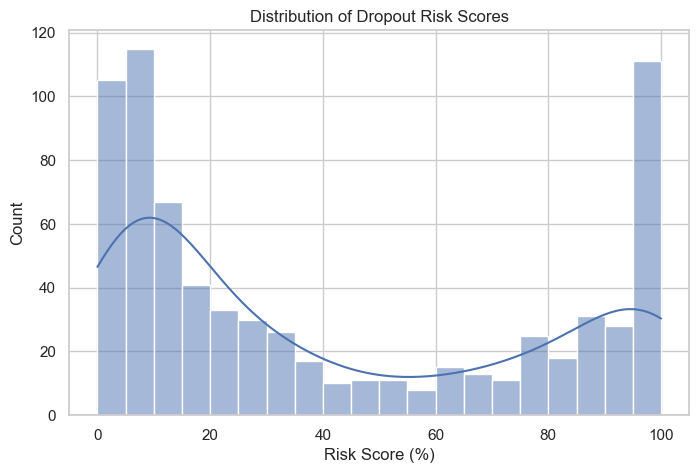

In [33]:
plt.figure(figsize=(8,5))
sns.histplot(results_df["Risk Score (%)"], bins=20, kde=True)

plt.title("Distribution of Dropout Risk Scores")
plt.xlabel("Risk Score (%)")
plt.ylabel("Count")

plt.show()

## 7.2. Risk Score Distribution by Actual Outcome

To better understand how well the risk score separates the two groups, the score distributions are compared for students who actually dropped out and students who actually graduated.

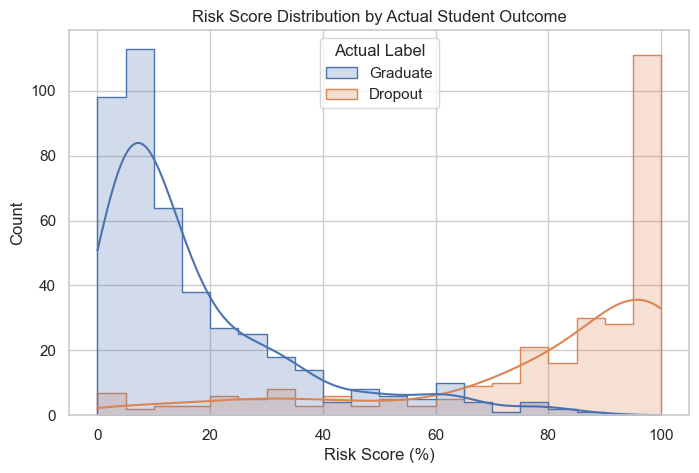

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(
  data=results_df,
  x="Risk Score (%)",
  hue="Actual Label",
  bins=20,
  kde=True,
  element="step"
)

plt.title("Risk Score Distribution by Actual Student Outcome")
plt.xlabel("Risk Score (%)")
plt.ylabel("Count")

plt.show()

## 7.3. Summary Statistics by Actual Outcome

To complement the visual analysis, summary statistics are calculated for the risk scores in each actual outcome group.

In [35]:
results_df.groupby("Actual Label")["Risk Score (%)"].describe()

,count,mean,std,min,25%,50%,75%,max
Actual Label,,,,,,,,
Dropout,284.0,79.020768,26.686434,0.0,71.513260,89.703219,100.000000,100.000000
Graduate,442.0,17.153211,17.508155,0.0,5.491627,10.560802,23.353744,88.555462


## 7.4. Average Risk Score by Actual Outcome

The mean risk score for each actual outcome group provides a simple summary of how differently the model scores graduates and dropouts.

In [36]:
avg_risk_by_outcome = results_df.groupby("Actual Label")["Risk Score (%)"].mean()

avg_risk_by_outcome

Actual Label
Dropout     79.020768
Graduate    17.153211
Name: Risk Score (%), dtype: float64

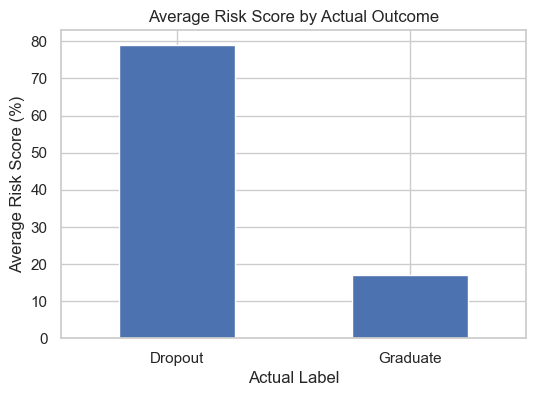

In [37]:
plt.figure(figsize=(6,4))
avg_risk_by_outcome.plot(kind="bar")

plt.title("Average Risk Score by Actual Outcome")
plt.ylabel("Average Risk Score (%)")
plt.xticks(rotation=0)

plt.show()

## 7.5. Interpretation

The distribution analysis shows that the predicted probabilities behave as meaningful dropout-related risk scores. Students who actually dropped out generally receive much higher risk scores, while students who graduated are concentrated more strongly in the low-risk range.

This pattern is also reflected in the summary statistics. The average risk score is approximately **79.02%** for dropout cases and **17.15%** for graduate cases, indicating strong separation between the two groups.

At the same time, some overlap remains between the distributions. This suggests that the risk score should be interpreted as an early warning indicator rather than a certain prediction. Overall, the results support the use of these scores for risk categorization, threshold selection, and early support planning.

# 8. Risk Category Design

The continuous risk scores become more useful in practice when they are translated into clear and interpretable risk categories. Instead of working only with raw percentages, students can be grouped into broader bands such as low, medium, and high risk.

This makes the results easier to communicate and allows the model output to be used more naturally in an early intervention setting. Risk categories can help universities decide which students may only require normal monitoring, which may benefit from additional review, and which may need more immediate support.

## 8.1. Define Risk Categories

To make the continuous risk scores easier to interpret, three risk bands are defined:

  * Low Risk: 0% to below 30%
  * Medium Risk: 30% to below 60%
  * High Risk: 60% and above

These ranges are used as an initial practical framework for grouping students based on their estimated dropout-related risk.

In [38]:
def assign_risk_category(score):
  if score < 30:
    return "Low Risk"
  elif score < 60:
    return "Medium Risk"
  else:
    return "High Risk"

In [39]:
results_df["Risk Category"] = results_df["Risk Score (%)"].apply(assign_risk_category)

results_df.head(10)

,Actual Outcome,Predicted Risk Score,Risk Score (%),Actual Label,Risk Category
0,0,0.010401,1.040075,Graduate,Low Risk
1,0,0.162577,16.257693,Graduate,Low Risk
2,1,0.340720,34.071973,Dropout,Medium Risk
3,0,0.283259,28.325882,Graduate,Low Risk
4,0,0.600824,60.082411,Graduate,High Risk
5,0,0.027494,2.749365,Graduate,Low Risk
6,0,0.221548,22.154784,Graduate,Low Risk
7,1,0.957530,95.753018,Dropout,High Risk
8,0,0.501984,50.198402,Graduate,Medium Risk
9,1,0.753585,75.358542,Dropout,High Risk


### 8.1.1. Initial Justification of Risk Band Thresholds

The risk bands used in this notebook are intended as an **initial practical framework** for interpreting the regression-based dropout-related risk scores. The cutoffs of 30% and 60% were selected to create three clearly distinguishable groups:

  * students with relatively low estimated dropout-related risk,  
  * students with moderate estimated risk who may benefit from closer review,  
  * students with high estimated risk who may require earlier support.  

These thresholds were not derived from a formal optimization procedure. Instead, they were chosen as interpretable decision boundaries that make the model output easier to communicate in an early intervention context.

Their usefulness is evaluated in the following sections by examining how students are distributed across categories and how the observed dropout rate differs between the `Low Risk`, `Medium Risk`, and `High Risk` groups. If the categories correspond to clearly different observed outcomes, this would support their practical relevance.

These thresholds should therefore be understood as exploratory and support-oriented rather than fixed institutional rules.

The following sections evaluate whether these exploratory category boundaries correspond to clearly different observed dropout patterns.

## 8.2. Distribution of Students Across Risk Categories

After defining the categories, the number of students in each risk group can be examined.

In [40]:
risk_category_counts = results_df["Risk Category"].value_counts()

risk_category_counts

Risk Category
Low Risk       391
High Risk      252
Medium Risk     83
Name: count, dtype: int64

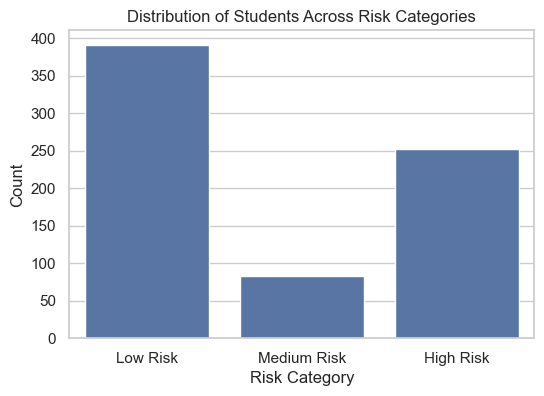

In [41]:
plt.figure(figsize=(6,4))
sns.countplot(x="Risk Category", data=results_df, order=["Low Risk", "Medium Risk", "High Risk"])

plt.title("Distribution of Students Across Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Count")

plt.show()

## 8.3. Percentage of Students in Each Risk Category

To better understand the relative size of each group, the **percentage** of students in each category is also calculated.

In [42]:
risk_category_percentages = results_df["Risk Category"].value_counts(normalize=True) * 100
risk_category_percentages = risk_category_percentages.reindex(["Low Risk", "Medium Risk", "High Risk"])

risk_category_percentages

Risk Category
Low Risk       53.856749
Medium Risk    11.432507
High Risk      34.710744
Name: proportion, dtype: float64

## 8.4. Actual Dropout Rate Within Each Risk Category

A useful way to evaluate whether the categories are meaningful is to examine the actual dropout rate within each group.

If the categories work well, the dropout rate should be:

  * lowest in the low-risk group
  * higher in the medium-risk group
  * highest in the high-risk group

In [43]:
dropout_rate_by_category = results_df.groupby("Risk Category")["Actual Outcome"].mean() * 100

dropout_rate_by_category = dropout_rate_by_category.reindex(["Low Risk", "Medium Risk", "High Risk"])
dropout_rate_by_category

Risk Category
Low Risk        6.649616
Medium Risk    33.734940
High Risk      91.269841
Name: Actual Outcome, dtype: float64

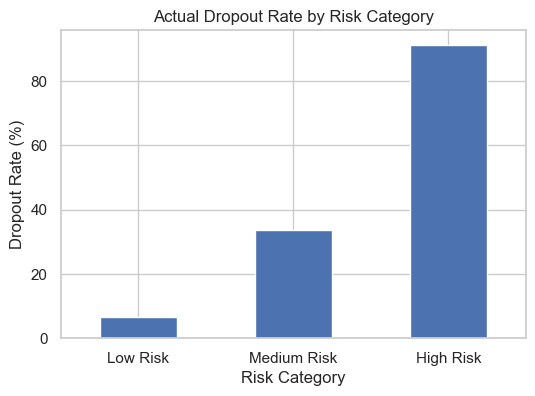

In [44]:
plt.figure(figsize=(6,4))
dropout_rate_by_category.plot(kind="bar")

plt.title("Actual Dropout Rate by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Dropout Rate (%)")
plt.xticks(rotation=0)

plt.show()

## 8.5. Crosstab of Risk Category and Actual Outcome

To see the relationship more directly, a crosstab can also be created.

In [45]:
pd.crosstab(results_df["Risk Category"], results_df["Actual Label"])

Actual Label,Dropout,Graduate
Risk Category,,
High Risk,230,22
Low Risk,26,365
Medium Risk,28,55


## 8.6 Interpretation

The risk category analysis shows that the percentage-based scores can be translated into meaningful and practical student groups. The three categories correspond to clearly different levels of observed dropout risk.

The `Low Risk` group has a dropout rate of only **6.2%**, while the `Medium Risk` group rises to **35.8%**. The `High Risk` group has a dropout rate of **91.1%**, showing that students in this category are very strongly associated with historical dropout patterns.

Overall, these results suggest that the selected risk bands provide a useful framework for communicating model output and supporting different levels of monitoring, review, and early intervention.

# 10. Calibration Analysis

The previous sections showed that the selected model produces strong classification results and meaningful risk scores. However, a risk scoring system should not only separate students well — it should also provide probabilities that are reasonably reliable as probability estimates.

`Calibration analysis` is used to evaluate whether the predicted dropout probabilities are aligned with the actual observed dropout frequencies. In other words, it helps assess whether a predicted risk score of, for example, 70% corresponds to a group in which approximately 70% of students actually drop out.

This is especially important in this notebook because the model output is being interpreted as a percentage-based early risk indicator rather than only as a binary class prediction.

## 10.1. Calibration Curve

A calibration curve compares the model’s predicted probabilities with the actual observed frequency of dropout across different probability ranges.

If the model is well calibrated, the calibration curve should stay close to the `diagonal reference line`.

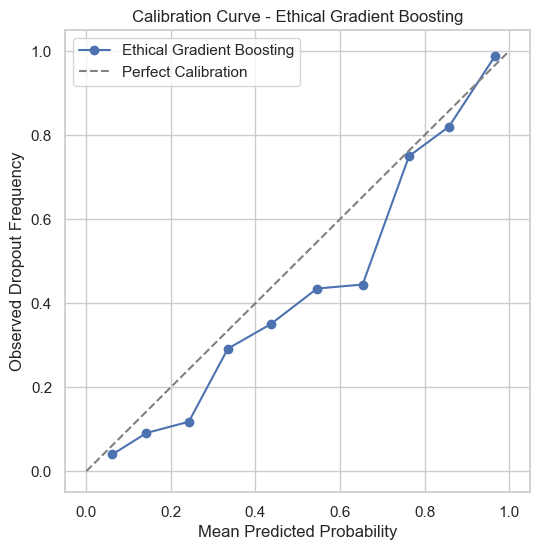

In [ ]:
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker="o", label="Ethical Gradient Boosting")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Perfect Calibration")

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Dropout Frequency")
plt.title("Calibration Curve - Ethical Gradient Boosting")
plt.legend()

plt.show()

## 10.2. Brier Score

`The Brier score` provides a numerical summary of how close the predicted probabilities are to the actual outcomes.

A lower Brier score indicates better probability calibration, with 0 representing a perfect score.

In [ ]:
brier = brier_score_loss(y_test, y_probs)

print("Brier Score:", brier)

Brier Score: 0.07606170965662556


## 10.3. Interpretation

The calibration analysis suggests that the predicted probabilities are reasonably reliable as dropout-related risk scores. The calibration curve stays fairly close to the diagonal line, especially at higher probability values.

Some deviation is still visible in the middle range, so the percentages should be interpreted as **approximate indicators** rather than exact probabilities. The Brier score of 0.076 also supports the overall quality of the probability estimates.

Overall, the model appears suitable for practical risk scoring, while still requiring careful interpretation.

# 11. Support Capacity Simulation

In practice, universities may not have enough resources to provide intensive support to every student with elevated risk. For this reason, a risk scoring system can also be used to prioritize students when support capacity is limited.

This section simulates a simple support-allocation scenario by ranking students according to their predicted dropout-related risk score and then examining how many actual dropout cases are captured within the highest-risk groups.

## 11.1. Rank Students by Risk Score

The students in the test set are ranked from highest to lowest predicted risk.

In [ ]:
results_df_ranked = results_df.sort_values(by="Risk Score (%)", ascending=False).reset_index(drop=True)
results_df_ranked.head(10)

,Actual Outcome,Predicted Class,Dropout Probability,Risk Score (%),Actual Label,Predicted Label,Risk Category
0,1,1,0.995183,99.518275,Dropout,Dropout,High Risk
1,1,1,0.994910,99.490990,Dropout,Dropout,High Risk
2,1,1,0.994581,99.458053,Dropout,Dropout,High Risk
3,1,1,0.994529,99.452935,Dropout,Dropout,High Risk
4,1,1,0.994389,99.438863,Dropout,Dropout,High Risk
5,1,1,0.993962,99.396211,Dropout,Dropout,High Risk
6,1,1,0.993454,99.345402,Dropout,Dropout,High Risk
7,1,1,0.993392,99.339204,Dropout,Dropout,High Risk
8,1,1,0.993184,99.318407,Dropout,Dropout,High Risk
9,1,1,0.993178,99.317826,Dropout,Dropout,High Risk


## 11.2. Simulate Support Capacity Levels

To explore how the model could be used in practice, several support-capacity levels are simulated:

  * top 10% highest-risk students
  * top 20% highest-risk students
  * top 30% highest-risk students

For each level, the number of selected students and the number of actual dropout cases captured are calculated.

In [ ]:
capacity_levels = [0.10, 0.20, 0.30]
capacity_results = []

total_dropouts = (results_df_ranked["Actual Outcome"] == 1).sum()
total_students = len(results_df_ranked)

for level in capacity_levels:
  n_students = int(total_students * level)
  selected = results_df_ranked.head(n_students)

  dropouts_captured = (selected["Actual Outcome"] == 1).sum()
  capture_rate = dropouts_captured / total_dropouts * 100

  capacity_results.append({
    "Support Capacity": f"Top {int(level * 100)}%",
    "Students Selected": n_students,
    "Actual Dropouts Captured": dropouts_captured,
    "Dropout Capture Rate (%)": capture_rate
  })

capacity_df = pd.DataFrame(capacity_results)
capacity_df

,Support Capacity,Students Selected,Actual Dropouts Captured,Dropout Capture Rate (%)
0,Top 10%,72,72,25.352113
1,Top 20%,145,145,51.056338
2,Top 30%,217,212,74.647887


## 11.3. Visualize Dropout Capture Rate

The capture rate shows what proportion of all actual dropout cases are included in the highest-risk student group at each support capacity level.

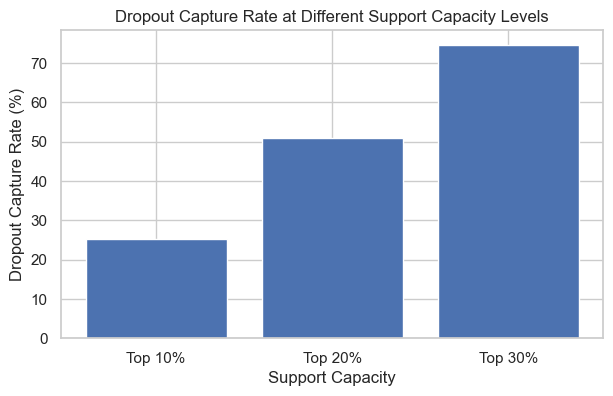

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(capacity_df["Support Capacity"], capacity_df["Dropout Capture Rate (%)"])

plt.title("Dropout Capture Rate at Different Support Capacity Levels")
plt.xlabel("Support Capacity")
plt.ylabel("Dropout Capture Rate (%)")

plt.show()

## 11.4. Visualize Number of Dropouts Captured

This second chart shows the absolute number of dropout cases captured at each capacity level.

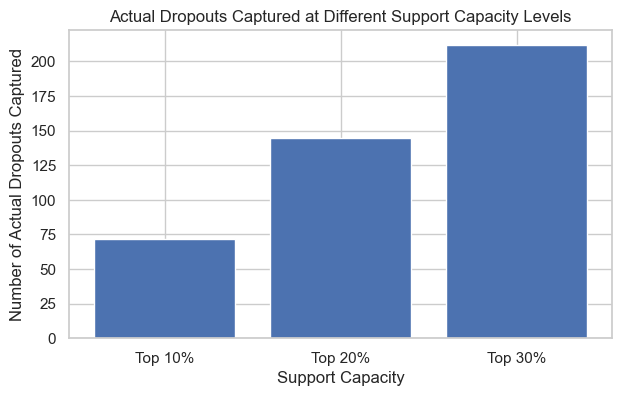

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(capacity_df["Support Capacity"], capacity_df["Actual Dropouts Captured"])

plt.title("Actual Dropouts Captured at Different Support Capacity Levels")
plt.xlabel("Support Capacity")
plt.ylabel("Number of Actual Dropouts Captured")

plt.show()

## 11.5. Interpretation

The support capacity simulation shows that the risk scores can be used effectively to prioritize students when support resources are limited. By focusing on the highest-risk students first, the model captures a substantial proportion of actual dropout cases.

If support can only be offered to the top 10% highest-risk students, the system captures 72 actual dropout cases, which represents approximately 25.4% of all dropout cases in the test set. Expanding support to the top 20% captures 145 dropout cases, or about 51.1% of the total. At the top 30% level, the system captures 212 dropout cases, corresponding to approximately 74.6% of all actual dropout cases.

These results suggest that the risk scoring framework can support practical intervention planning by helping institutions direct limited resources toward the students most strongly associated with dropout risk.

# 12. Practical and Ethical Interpretation

The previous sections showed that the selected model can generate meaningful dropout-related risk scores, group students into practical risk categories, support threshold-based intervention decisions, and help prioritize students when support capacity is limited. However, the use of such a system in a real educational setting requires careful interpretation.

This section reflects on how the risk scoring framework could be used in practice and what ethical precautions should be considered when interpreting the results.

## 12.1. Practical Use of Risk Scores

The risk scores developed in this notebook could support universities as an early warning tool for identifying students who may benefit from additional attention.

For example, institutions could use the scores to:

  * monitor students in the `Low Risk` group through normal academic processes  
  * review students in the `Medium Risk` group more closely  
  * prioritize students in the `High Risk` group for earlier support or outreach  

The support capacity simulation also shows that the scores can help allocate limited resources more effectively by focusing attention on the **highest-risk** students first.

At the same time, the model should not be understood as a replacement for academic advisors, teachers, or student support staff. Instead, it should be used as a decision-support tool that helps guide attention toward students who may need further review.

### 12.1.1. Example Support Actions by Risk Category

To illustrate how the risk categories could be used in practice, the table below presents example support responses that an institution might consider. These are only illustrative examples and should not be interpreted as fixed rules.

| Risk Category | Example Interpretation | Possible Support Response |
|---|---|---|
| **Low Risk** | Student currently shows relatively low estimated dropout-related risk | Normal monitoring through standard academic processes |
| **Medium Risk** | Student shows moderate estimated risk and may benefit from additional review | Advisor check-in, review of academic progress, optional support contact |
| **High Risk** | Student shows high estimated risk and may require earlier attention | Priority outreach, academic guidance, financial support review, mentoring referral |

The purpose of this table is not to automate interventions, but to show how probability-based risk categories could help organize support efforts in a structured and responsible way.

## 12.2. Ethical Use of Predictions

Although the model produces useful risk estimates, these predictions should be interpreted carefully and used responsibly.

A **high risk** score does not mean that a student will definitely drop out. It only means that the student’s profile is more strongly associated with historical patterns linked to dropout in the dataset. Similarly, a low risk score does not guarantee that a student is completely safe.

For this reason, the scores should be used to support helpful intervention, not punishment or exclusion. Their purpose should be to encourage academic guidance, mentoring, financial support, or other forms of assistance.

This notebook also uses the ethical feature set, which excludes sensitive demographic and family-background variables such as gender, nationality, and parental education or occupation. This reduces the likelihood that the model relies directly on potentially sensitive attributes when generating support-oriented predictions.

## 12.3. Limitations of Practical Use

Several limitations should still be considered when interpreting the results.

First, the dataset does not directly measure student struggle. The risk scores are derived from a binary dropout prediction model and should therefore be understood as dropout-related risk indicators, not as direct measures of personal difficulty.

Second, the model is based on historical data from a specific educational context. This means the results may not fully generalize to other institutions, student populations, or support systems.

Third, although the calibration analysis suggests that the predicted probabilities are reasonably reliable, the percentages should still be interpreted as approximate indicators rather than exact probabilities.

In addition, the results presented in this notebook are based on a single train/test split of the dataset. Although stratification was used and the selected model previously showed strong performance, the exact category distributions, threshold results, calibration pattern, and support-capacity outcomes may vary somewhat under different data splits. For this reason, these findings should be understood as indicative rather than as fixed operational performance guarantees.

Overall, the system appears useful as a support-oriented early warning framework, but it should always be applied with human judgment and institutional care.

## 12.4. Interpretation

The practical and ethical analysis suggests that the proposed risk scoring framework could be valuable as an early support tool in higher education. The model outputs are interpretable enough to guide monitoring, threshold-based review, and support prioritization, while the ethical feature selection helps reduce the risk of direct reliance on sensitive background variables.

At the same time, the results should not be treated as certain judgments about a student’s future. The scores are best understood as structured warning signals that can help institutions provide timely and responsible support.

# 13. Conclusion

This notebook extended the previous student dropout prediction analysis by translating classification outputs into a more interpretable risk scoring framework for early intervention.

Using the selected `Ethical Gradient Boosting` model, predicted dropout probabilities were converted into **percentage-based risk scores** and examined through multiple practical perspectives. The analysis showed that these scores meaningfully separate dropout and graduate cases, support the creation of clear risk categories, and provide useful guidance for threshold-based intervention decisions.

The results also showed that the risk categories correspond to clearly different levels of observed dropout risk, while the support capacity simulation demonstrated that the highest-risk students contain a large share of actual dropout cases. In addition, the calibration analysis suggested that the predicted probabilities are reasonably reliable as practical risk indicators.

Overall, this notebook shows that a binary classification model can be extended into a more useful and interpretable early warning system without introducing a separate regression task. Rather than relying only on a final yes-or-no prediction, the model can support universities with a more gradual view of student risk that may help guide earlier and more targeted support.

At the same time, the results should still be interpreted carefully. The scores are not direct measurements of student struggle, and they should not be used as final judgments. Instead, they are best understood as dropout-related support indicators that can assist human decision-making in a more responsible and practical way.